In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [21]:
## 2. LOAD STOCK DATA
stock_symbol = "AAPL"  # You can change this
data = yf.download(stock_symbol, period= '5y')

close_prices = data[['Close']].values

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)

[*********************100%***********************]  1 of 1 completed


In [ ]:
## 3. CREATE SEQUENCES (30 days -> 1 day)
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

sequence_length = 30
X, y = create_sequences(scaled_data, sequence_length)

In [ ]:
## 4. TRAIN / VALIDATION / TEST SPLIT

total_samples = len(X)

train_size = int(0.7 * total_samples)
val_size = int(0.2 * total_samples)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]


In [ ]:
## 5. CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [ ]:
## 6. MODEL A — SIMPLE RNN

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(sequence_length, 1)),
    Dense(1)
])

rnn_model.compile(
    optimizer=Adam(),
    loss='mse',
    metrics=['mae']
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/100


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0158 - mae: 0.0846 - val_loss: 0.0061 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014 - mae: 0.0296 - val_loss: 0.0049 - val_mae: 0.0589 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.9578e-04 - mae: 0.0242 - val_loss: 0.0023 - val_mae: 0.0353 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.5950e-04 - mae: 0.0226 - val_loss: 0.0023 - val_mae: 0.0368 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4669e-04 - mae: 0.0210 - val_loss: 0.0022 - val_mae: 0.0355 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.7881e-04 - mae: 0.0201 - val_loss: 0.0019 - val_mae: 0.0332 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4268e-04 - mae: 0.0195 - val_loss: 0.0017 - val_mae: 0.0303 - learning_rate: 0.0010
Epoc

In [ ]:
## 7. MODEL B — LSTM

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(sequence_length, 1)),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(),
    loss='mse',
    metrics=['mae']
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0185 - mae: 0.0984 - val_loss: 0.0213 - val_mae: 0.1381 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0024 - mae: 0.0377 - val_loss: 0.0043 - val_mae: 0.0548 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - mae: 0.0277 - val_loss: 0.0028 - val_mae: 0.0377 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - mae: 0.0263 - val_loss: 0.0034 - val_mae: 0.0415 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - mae: 0.0257 - val_loss: 0.0026 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.8057e-04 - mae: 0.0251 - val_loss: 0.0024 - val_mae: 0.0357 - learning_rate: 5.0000e-04
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7056e-04 - mae: 0.0250 - val_loss: 0.0025 - val_mae: 0.0362 - learning_rate: 5

In [18]:
# RNN Evaluation
rnn_pred = rnn_model.predict(X_test)
rnn_pred_inv = scaler.inverse_transform(rnn_pred)
y_test_inv = scaler.inverse_transform(y_test)

rnn_mse = mean_squared_error(y_test_inv, rnn_pred_inv)
rnn_mae = mean_absolute_error(y_test_inv, rnn_pred_inv)

# LSTM Evaluation
lstm_pred = lstm_model.predict(X_test)
lstm_pred_inv = scaler.inverse_transform(lstm_pred)

lstm_mse = mean_squared_error(y_test_inv, lstm_pred_inv)
lstm_mae = mean_absolute_error(y_test_inv, lstm_pred_inv)

print("===== RNN Results =====")
print("Test MSE:", rnn_mse)
print("Test MAE:", rnn_mae)

print("\n===== LSTM Results =====")
print("Test MSE:", lstm_mse)
print("Test MAE:", lstm_mae)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
===== RNN Results =====
Test MSE: 31.812745285788324
Test MAE: 4.516717678163111

===== LSTM Results =====
Test MSE: 1529.2325182730197
Test MAE: 38.39352020015561


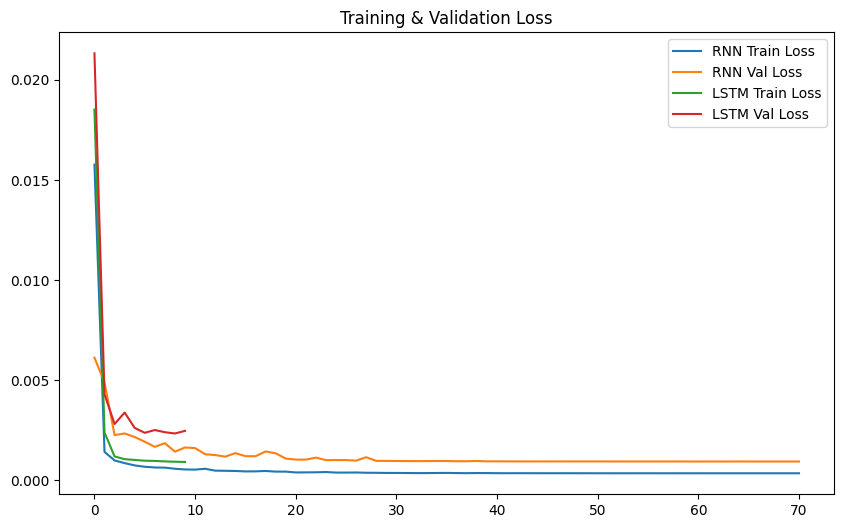

In [ ]:
# 9. LOSS CURVES

plt.figure(figsize=(10,6))
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
plt.legend()
plt.title("Training & Validation Loss")
plt.show()


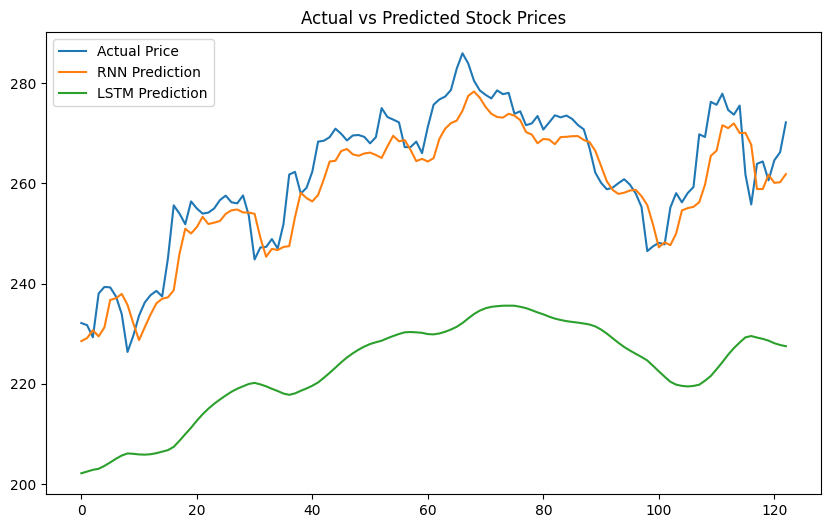

In [ ]:
# 10. PREDICTION VISUALIZATION

plt.figure(figsize=(10,6))
plt.plot(y_test_inv, label='Actual Price')
plt.plot(rnn_pred_inv, label='RNN Prediction')
plt.plot(lstm_pred_inv, label='LSTM Prediction')
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()